## ResNet152v2 model 

# libraries

In [82]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.utils import plot_model #for model visualization

In [83]:
with_mask_data = os.listdir(r'C:\Users\jackb\facemask\archive (13)\data\with_mask')

In [84]:
print(with_mask_data[0:5])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']


In [85]:
print('Number of with mask images:', len(with_mask_data))

Number of with mask images: 3725


In [86]:
without_mask_data = os.listdir(r'C:\Users\jackb\facemask\archive (13)\data\without_mask')

In [87]:
print(without_mask_data[0:5])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']


In [88]:
print('Number of without mask images:', len(without_mask_data))

Number of without mask images: 3828


## Pre- Processing

In [89]:
with_mask_labels = [1]*len(with_mask_data)
print(f"With Mask labels" ,with_mask_labels[0:10])

without_mask_labels = [0]*len(without_mask_data)
print(f"Without Mask Labels", without_mask_labels[0:10])

With Mask labels [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Without Mask Labels [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [90]:
Labels = with_mask_labels + without_mask_labels
print(f"Labels", Labels[0:10])
print(f"Labels", Labels[-10:])

Labels [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Labels [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


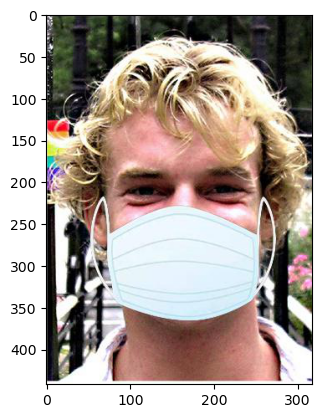

In [91]:
#display any image from with_mask_data randomly
import random
random_image = random.choice(with_mask_data)
img = Image.open('archive (13)/data/with_mask' + '/' + random_image)
plt.imshow(img)


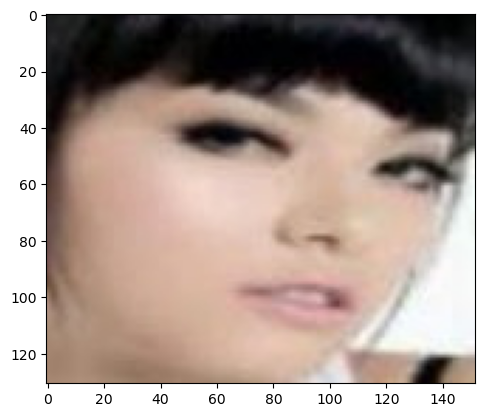

In [92]:
#display any image from without_mask_data randomly
import random
random_image = random.choice(without_mask_data)
img = Image.open(r'archive (13)/data/without_mask' + '/' + random_image)
plt.imshow(img)


In [93]:
#resize images and convert to numpy array


images = []
def load_images_from_folder(folder):
    
    for filename in os.listdir(folder):
        img = Image.open(os.path.join(folder,filename))
        img = img.resize((128,128))
        img = img.convert('RGB')
        images.append(np.array(img))
    return images

with_mask_images = load_images_from_folder(r'archive (13)/data/with_mask')
without_mask_images = load_images_from_folder(r'archive (13)/data/without_mask')

C:\Users\jackb\anaconda3\Lib\site-packages\PIL\Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [94]:
type(images)

list

In [95]:
images[0]

array([[[50, 58, 31],
        [46, 54, 34],
        [56, 59, 42],
        ...,
        [26, 32, 25],
        [29, 33, 18],
        [34, 40, 16]],

       [[47, 55, 30],
        [49, 57, 37],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [38, 42, 31],
        [31, 41, 22]],

       [[52, 58, 37],
        [50, 59, 38],
        [59, 64, 36],
        ...,
        [45, 44, 30],
        [29, 35, 28],
        [20, 30, 17]],

       ...,

       [[63, 72, 37],
        [66, 76, 41],
        [74, 84, 50],
        ...,
        [ 5,  4,  0],
        [20, 19, 15],
        [17, 17, 12]],

       [[59, 71, 34],
        [60, 70, 39],
        [68, 76, 50],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 29],
        [54, 64, 37],
        [57, 63, 43],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [20, 12, 13]]], dtype=uint8)

In [96]:
len(images)

7553

In [97]:
images[0].shape

(128, 128, 3)

In [98]:
type(images)

list

In [99]:
type(Labels)

list

In [100]:
X = np.array(images)
Y = np.array(Labels)

In [101]:
type(X)

numpy.ndarray

In [102]:
print(X.shape)

(7553, 128, 128, 3)


In [103]:
X[0]

array([[[50, 58, 31],
        [46, 54, 34],
        [56, 59, 42],
        ...,
        [26, 32, 25],
        [29, 33, 18],
        [34, 40, 16]],

       [[47, 55, 30],
        [49, 57, 37],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [38, 42, 31],
        [31, 41, 22]],

       [[52, 58, 37],
        [50, 59, 38],
        [59, 64, 36],
        ...,
        [45, 44, 30],
        [29, 35, 28],
        [20, 30, 17]],

       ...,

       [[63, 72, 37],
        [66, 76, 41],
        [74, 84, 50],
        ...,
        [ 5,  4,  0],
        [20, 19, 15],
        [17, 17, 12]],

       [[59, 71, 34],
        [60, 70, 39],
        [68, 76, 50],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 29],
        [54, 64, 37],
        [57, 63, 43],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [20, 12, 13]]], dtype=uint8)

In [104]:
type(Y)

numpy.ndarray

In [105]:
print(Y.shape)

(7553,)


In [106]:
Y

array([1, 1, 1, ..., 0, 0, 0])

## **<font color = #8b7a5e>Train Test Split</font>**

In [107]:
#split the data into training and testing

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [108]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of Y_train is: {Y_train.shape}\n")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of Y_test is: {Y_test.shape}")

Shape of X_train is: (6042, 128, 128, 3)
Shape of Y_train is: (6042,)

Shape of X_test is: (1511, 128, 128, 3)
Shape of Y_test is: (1511,)


## **<font color = #8b7a5e>Scaling The data</font>**

In [109]:
#scaling the data
X_train = X_train/255
X_test = X_test/255

print(X_train.shape)
print(X_test.shape)

(6042, 128, 128, 3)
(1511, 128, 128, 3)


## ResNet Implementation

### **<font color = "purple">Model Structure</font>**

In [110]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten ,Dense ,Dropout ,BatchNormalization
from tensorflow.keras.optimizers import Adamax

image_size = (128,128)
channels = 3
image_shape = (image_size[0],image_size[1], channels)

base_model = tf.keras.applications.ResNet152V2(
    include_top=False,
    weights="imagenet",
     input_shape=image_shape)

model = Sequential([
    base_model,
    Flatten(),
    BatchNormalization(),
    Dense(128, activation ='relu'),
    Dropout(rate=0.2),
    
    Dense(2, activation ='sigmoid')
    
])

### **<font color = "purple">Model Compiling</font>**

In [111]:


model.compile(Adamax(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### **<font color = "purple">Model Summary</font>**

In [112]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet152v2 (Functional)        │ ?                      │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,331,648 (222.52 MB)

 Trainable params: 58,187,904 (221.97 MB)

 Non-trainable params: 143,744 (561.50 KB)

### **<font color = "purple">Model Fitting</font>**

In [113]:
history = model.fit(X_train, Y_train, epochs=10, validation_split=0.1)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3155s 18s/step - accuracy: 0.8987 - loss: 0.3275 - val_accuracy: 0.9702 - val_loss: 0.2128
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 2922s 17s/step - accuracy: 0.9841 - loss: 0.0457 - val_accuracy: 0.9818 - val_loss: 0.0951
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3018s 18s/step - accuracy: 0.9936 - loss: 0.0216 - val_accuracy: 0.9802 - val_loss: 0.0916
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3099s 18s/step - accuracy: 0.9978 - loss: 0.0079 - val_accuracy: 0.9851 - val_loss: 0.0690
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3120s 18s/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9785 - val_loss: 0.2205
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3084s 18s/step - accuracy: 0.9932 - loss: 0.0271 - val_accuracy: 0.9818 - val_loss: 0.0776
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3135s 18s/step - accuracy: 0.9976 - loss: 0.0125 - val_accuracy: 0.9736 - val_loss: 0.1262
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3110s 18s/step - accuracy: 0.9917 - loss: 0

### **<font color = "purple">Model Evaluation</font>**

In [114]:
loss, accuracy = model.evaluate(X_test, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 334s 7s/step - accuracy: 0.9858 - loss: 0.0556
Test Accuracy = 0.9880873560905457


In [115]:
#Classification Report
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(Y_test, y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 345s 7s/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       750
           1       0.99      0.99      0.99       761

    accuracy                           0.99      1511
   macro avg       0.99      0.99      0.99      1511
weighted avg       0.99      0.99      0.99      1511



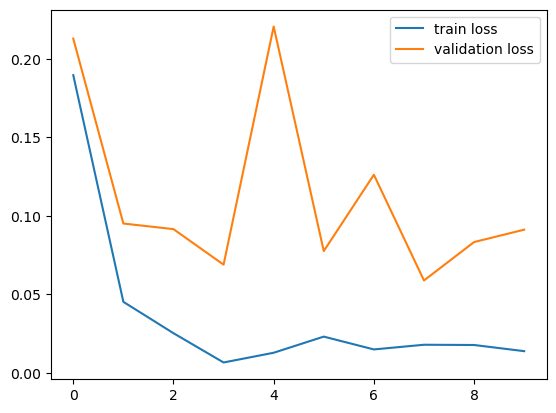

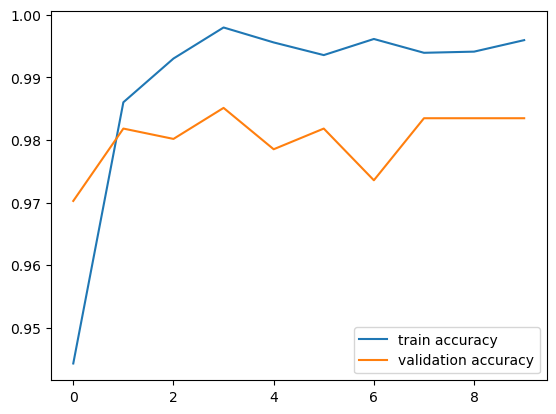

In [116]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['accuracy'], label='train accuracy')
plt.plot(h.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()

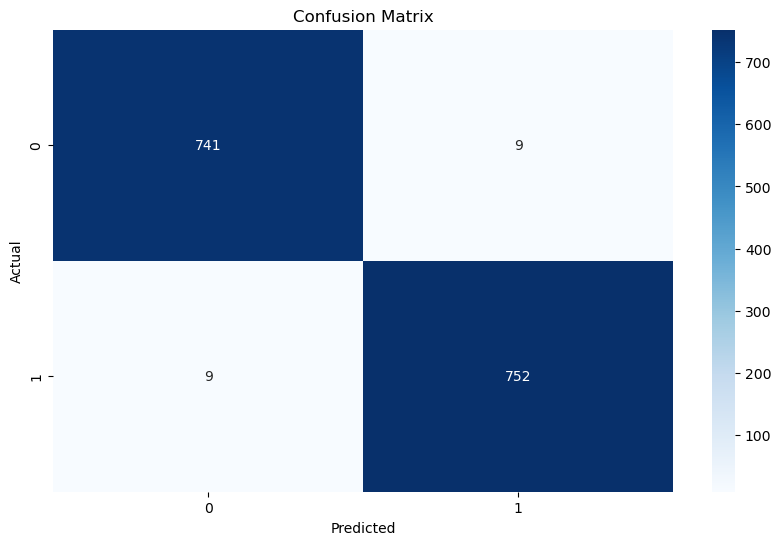

In [117]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
#plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

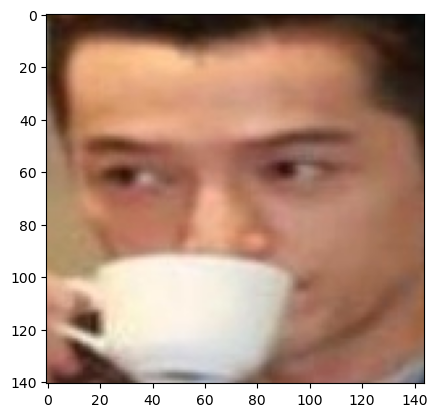

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
[[4.070262e-04 9.976623e-01]]
1
The person in the image is wearing a mask


In [142]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Assuming model is loaded somewhere before this code snippet

input_image_path = 'archive (13)/data/without_mask/without_mask_1002.jpg'
input_image = cv2.imread(input_image_path)

# plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
# plt.show()

plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
plt.show()

input_image_resized = cv2.resize(input_image, (128, 128))

input_image_scaled = input_image_resized / 255  # Assuming model requires normalized input

input_image_reshaped = np.reshape(input_image_scaled, [1, 128, 128, 3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')


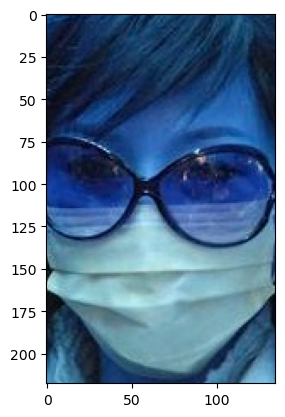

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
[[4.3114874e-06 9.9994320e-01]]
1
The person in the image is wearing a mask


In [141]:
input_image_path = 'archive (13)/data/with_mask/with_mask_10.jpg'

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.show()

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

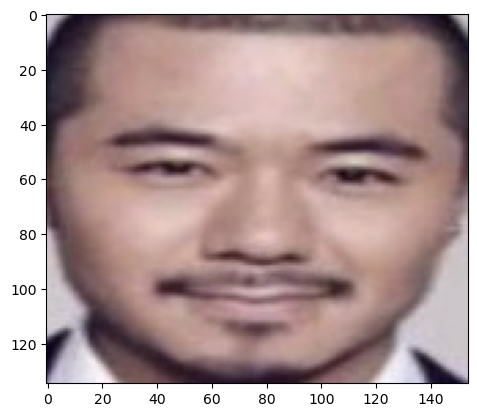